<a href="https://colab.research.google.com/github/m-ony/mineria-de-datos/blob/main/Proyecto_de_Miner%C3%ADa_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Minería de Datos Reconocimiento de Voz "Luz Inteligente"



> Equipo:
  - Monica Hermamdez Quiroz
  - Fernanda Daniela Garcia Camacho



> Grupo



> Fecha: 25 de mayo de 2026










Indice

##Introducción

Este proyecto tiene como objetivo el diseño e implementación de un algoritmo de predicción capaz de clasificar dos estados acústicos:

- Luz encendida

- Luz apagada

Para ello se empleará una Red Neuronal Artificial (RNA) de tipo densa (Multilayer Perceptron, MLP), entrenada con características extraídas mediante MFCC. El modelo será desarrollado en Python, aprovechando librerías especializadas como librosa para la extracción de características, numpy y pandas para la manipulación de datos, y tensorflow/keras para la construcción y entrenamiento de la red neuronal.

###Procesamiento de audio

El procesamiento de audio es la manipulación y mejora de señales sonoras mediante técnicas analógicas o digitales para optimizar su calidad, transmisión o transformación.

###Redes neuronales densas


Una red neuronal esta isnpirada en la estructura del cerebro humano.Está compuesta por una gran cantidad de "neuronas" artificiales organizadas en capas.


El proceso es el siguiente:

- Capa de Entrada: Recibe los datos en bruto (por ejemplo, los píxeles de una imagen o el precio de una casa).

- Capas Ocultas: Conjunto de capas intermedias donde la red aprende. Cada neurona en estas capas recibe información de muchas neuronas de la capa anterior, realiza un cálculo y, si el resultado supera un cierto umbral, "se activa" y pasa su información a la siguiente capa.

- Capa de Salida: Produce el resultado final, como la probabilidad de que una imagen sea un perro o un gato, o el precio estimado de una casa.

Las redes neuronales densas son un tipo de red neuronal artificial en la que las neuronas están organizadas en capas, cada neurona de una capa está conectada a todas las neuronas de la capa siguiente. Este tipo de red es especialmente útil para problemas de clasificación y regresión, ya que puede aprender representaciones jerárquicas de los datos.

###Uso de MFCC

Los coeficientes cepstrales de frecuencia Mel (MFCC) son utilizados en diversas aplicaciones en el procesamiento de señales de audio, especialmente en el reconocimiento automático del discurso y la recuperación de información musical. Se utilizan para extraer características relevantes de señales de audio, filtrando características irrelevantes como el ruido de fondo, emociones o volumen.


##Desarrollo

###Importación de librerias

Instalar e importar las siguientes librerías:

librosa → procesamiento de audio
numpy → operaciones matemáticas
tensorflow.keras → construcción del modelo

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
import os

from glob import glob
import tensorflow as tf

###Dataset

In [11]:
#Extracción de audios por medio de glob
audios=glob('/content/drive/MyDrive/Librosa/*/*.wav')
#audios

['/content/drive/MyDrive/Librosa/apagarluz/Apagar_Luz_18.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar_luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar Luz (1).wav',
 '/content/drive/MyDrive/Librosa/apagarluz/LUZ ENCENDIDA.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/LUZ APAGADA.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar_Luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar_luz (2).wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar1.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar2.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar3.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar_.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar-Luz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagarluz.wav',
 '/content/drive/MyDrive/Librosa/apagarluz/Apagar_Luz (1).wav',
 '/content/drive/MyDrive/Librosa/apagarluz/apagar-luz.wav',
 '/content/drive/MyDrive/Librosa/a

In [12]:
ipd.Audio(audios[0])

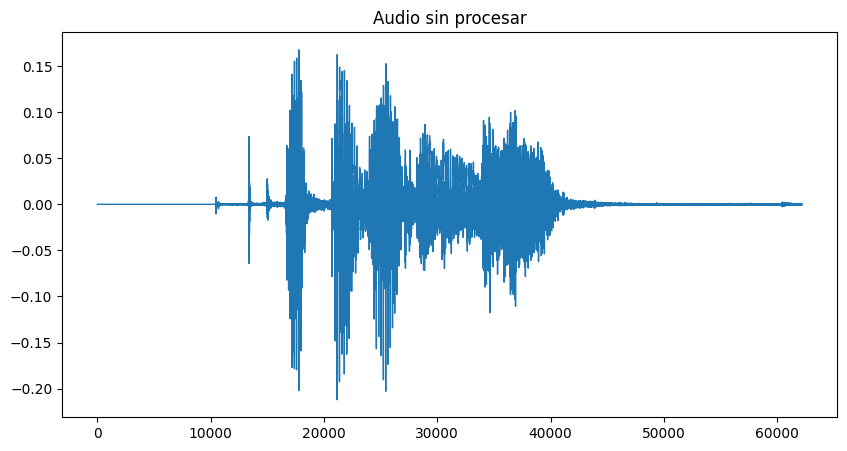

In [14]:
#Ejemplo
y, sr= librosa.load(audios[0])
pd.Series(y).plot(figsize=(10,5), lw=1, title="Audio sin procesar")
plt.show()

####MFCC, Padding y Normalización

In [15]:
def extraer_mfcc(n):
  #Definimos el tamaño estándar que queremos para TODO el proyecto,
  #cada columna de un MFCC representa 23 milisegundos de audio (aproximadamente)
  #los audios miden aproximamente 2 min
  max_columnas = 120
  y, sr= librosa.load(n)
  mfcc=librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

  #padding
  columnas_actuales = mfcc.shape[1]
  if columnas_actuales < max_columnas:
    pad_width = max_columnas - columnas_actuales
    mfcc_listo = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')

  else:
    mfcc_listo = mfcc[:, :max_columnas]

  return mfcc_listo

# n_mfcc cuántas características o "pistas" de audio quieres extraer de cada fragmento de tiempo

In [16]:
X_datos=[]
for i in audios:
  mfcc=extraer_mfcc(i)
  X_datos.append(mfcc)
  #print(mfcc.shape)
dataset=np.array(X_datos)
print(dataset.shape)

/tmp/ipykernel_33883/1633950996.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(n)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_33883/1633950996.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(n)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_33883/1633950996.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr= librosa.load(n)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.a

(40, 20, 120)


In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Alanamos la matriz 3D a 2D (obligatorio para scikit-learn)
num_audios = dataset.shape[0]
X_plano = dataset.reshape(num_audios, -1)

# Aplicamos el escalador para dejar todo entre 0 y 1
# Toma el valor de audio más bajo y lo vuelve 0, y el más alto lo vuelve 1.
# Todo lo demás lo "encierra" proporcionalmente entre 0 y 1.
escalador_0_1 = MinMaxScaler(feature_range=(0, 1))
data= escalador_0_1.fit_transform(X_plano)

# Centramos los datos en cero con varianza 1
#Resta el promedio y divide entre la desviación. Centra todos los datos en el 0.
#Los valores no tienen un límite fijo, pero la mayoría queda cerca del cero.
estandarizador = StandardScaler()
data_estandarizado = estandarizador.fit_transform(X_plano)

###Preparando datos de entrenamiento y prueba


In [18]:
#Aqui se creo nuestro arreglo de salaida o resultados para nuestra red neuronal
y_salidas=[]
for i in audios:
  ruta = i.lower()
  if("encender" in ruta):
    y_salidas.append(1)
  elif("apagar"):
    y_salidas.append(0)
y_salidas=np.array(y_salidas)

In [19]:
from sklearn.model_selection import train_test_split
#Obtenemos de nuestro dataset el 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(data, y_salidas, test_size=0.2, random_state=42, stratify=y_salidas)

print("Para entrenar la red neuronal usarás:", X_train.shape, "con sus respuestas:", y_train.shape)
print("Para evaluar la red neuronal usarás:", X_test.shape, "con sus respuestas:", y_test.shape)

Para entrenar la red neuronal usarás: (32, 2400) con sus respuestas: (32,)
Para evaluar la red neuronal usarás: (8, 2400) con sus respuestas: (8,)


###Modelo de predicción

In [20]:
#Creación del modelo, con tres capas ocultas
modelo= tf.keras.Sequential([tf.keras.layers.Flatten(),
                             tf.keras.layers.Dense(65, activation='relu'),#capa oculta 1
                             tf.keras.layers.Dense(35, activation='relu'),#capa oculta 2
                             #tf.keras.layers.Dense(55, activation='relu'),#capa aculta 3
                             tf.keras.layers.Dense(1, activation='sigmoid')
                             ])

In [21]:
#compilación del modelo
modelo.compile(
    optimizer='adam',
    loss='binary_crossentropy', #para clasificación
    metrics=['accuracy']
)

In [22]:
historial=modelo.fit(X_train,y_train,epochs=15,batch_size=4)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5312 - loss: 0.9922
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7188 - loss: 0.6695
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4375 - loss: 0.8698
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5625 - loss: 0.6715
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7500 - loss: 0.6261
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.5858
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8125 - loss: 0.5542
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8438 - loss: 0.5055
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8125 - loss: 0.4796
Epoch 10/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9062 - loss: 0.4250
Epoch 11/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8125 - loss: 0.4223
Epoch 12/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6562 - loss: 0.4975
E

###Graficas

Grafica de Pérdida

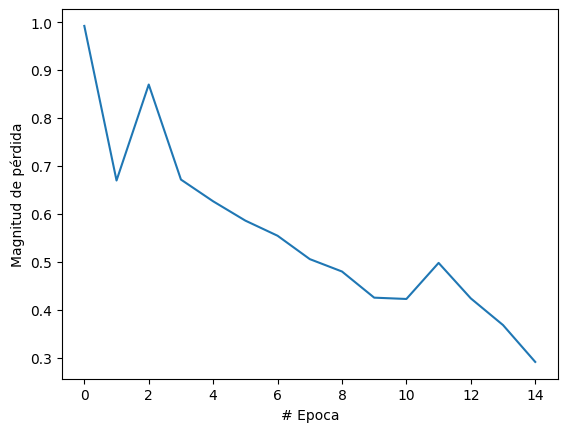

In [23]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"], label="Pérdida de entrenamiento")

Gráfica de Precisión

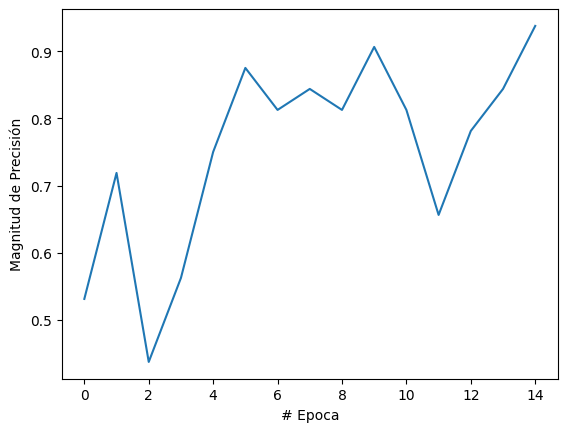

In [24]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de Precisión")
plt.plot(historial.history["accuracy"], label="Precisión de entrenamiento")

###Pruebas

In [25]:
predicciones_numericas = modelo.predict(X_test)

print("=== PROBANDO EL SISTEMA EN TIEMPO REAL ===")
for i in range(len(predicciones_numericas)):
    probabilidad = predicciones_numericas[i][0]

    # La lógica de umbral que te pidieron:
    if probabilidad >= 0.5:
        resultado_sistema = "Luz Encendida"
    else:
        resultado_sistema = "Luz Apagada"

    respuesta_real = "Luz Encendida" if y_test[i] == 1 else "Luz Apagada"
    print(f"Audio #{i+1}: Probabilidad: {probabilidad:.4f} -> [{resultado_sistema}] | Real: {respuesta_real}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
=== PROBANDO EL SISTEMA EN TIEMPO REAL ===
Audio #1: Probabilidad: 0.4883 -> [Luz Apagada] | Real: Luz Apagada
Audio #2: Probabilidad: 0.7419 -> [Luz Encendida] | Real: Luz Apagada
Audio #3: Probabilidad: 0.2933 -> [Luz Apagada] | Real: Luz Encendida
Audio #4: Probabilidad: 0.4171 -> [Luz Apagada] | Real: Luz Encendida
Audio #5: Probabilidad: 0.9066 -> [Luz Encendida] | Real: Luz Apagada
Audio #6: Probabilidad: 0.5097 -> [Luz Encendida] | Real: Luz Encendida
Audio #7: Probabilidad: 0.4231 -> [Luz Apagada] | Real: Luz Apagada
Audio #8: Probabilidad: 0.4479 -> [Luz Apagada] | Real: Luz Encendida
